In [ ]:
# Student Performance Insights — Statistical Analysis & Hypothesis Testing

### Data Science with Python — Week 3 Project

This project analyzes student performance data using descriptive statistics, exploratory data analysis, hypothesis testing, confidence intervals, and effect-size measures.

The analysis focuses on understanding whether factors such as test preparation and parental education are associated with differences in student performance.

**Developed by Rohan Bhowmik**

In [ ]:
## Research Questions

This project investigates three major statistical questions:

1. **Does completing a test-preparation course relate to higher average student scores?**
2. **Does parental education level relate to differences in student performance?**
3. **Is test-preparation status associated with student pass/fail status?**

### Statistical Settings

- Significance level (α): **0.05**
- Confidence level: **95%**
- Null hypothesis (H₀): No statistically significant difference/association exists.
- Alternative hypothesis (H₁): A statistically significant difference/association exists.

A p-value below 0.05 is treated as statistically significant.

> Statistical significance does not automatically imply practical importance or causation.

In [1]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from statsmodels.stats.proportion import proportion_confint

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

ALPHA = 0.05
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
## 1. Load the Dataset

The dataset used for this project is:

`student_performance_statistical_analysis.csv`

The CSV file is kept in the same project folder as this notebook so that the analysis remains portable and reproducible.

In [3]:
# Load the dataset from the Documents folder

import os
import pandas as pd

file_path = os.path.expanduser(
    r"~/Documents/student_performance_statistical_analysis.csv"
)

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (1200, 18)


,student_id,gender,age,school,address,parental_education,study_time,test_preparation,internet_access,family_support,extracurricular_activities,lunch_type,absences,math_score,reading_score,writing_score,average_score,pass_status
0,STU10001,Male,18,School A,Urban,Some College,2-5 hours,Completed,Yes,Yes,Yes,Standard,3,66.100,70.700,71.900,69.600,Pass
1,STU10002,Female,18,School B,Urban,High School,<2 hours,Completed,Yes,Yes,Yes,Standard,3,67.800,71.600,61.900,67.100,Pass
2,STU10003,Male,20,School B,Urban,High School,2-5 hours,Completed,Yes,No,No,Standard,9,64.800,62.900,61.600,63.100,Pass
3,STU10004,Male,19,School B,Urban,Associate,<2 hours,NaN,Yes,Yes,Yes,Reduced,8,53.800,68.900,70.900,64.500,Pass
4,STU10005,Female,15,School B,Rural,Bachelor,<2 hours,NaN,No,Yes,Yes,Standard,3,60.600,68.100,73.200,67.300,Pass


In [ ]:
## 2. Data Quality & Preparation

Before performing statistical analysis, the dataset is checked for:

- Missing values
- Duplicate records
- Data types
- Unique values
- Data consistency

In [4]:
# Data quality report

print("Data Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nNumber of Unique Values:")
display(df.nunique().to_frame("Unique Values"))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Information:")
df.info()

Data Types:


,Data Type
student_id,object
gender,object
age,int64
school,object
address,object
parental_education,object
study_time,object
test_preparation,object
internet_access,object
family_support,object



Missing Values:


,Missing Values
student_id,0
gender,0
age,0
school,0
address,0
parental_education,0
study_time,0
test_preparation,694
internet_access,0
family_support,0



Number of Unique Values:


,Unique Values
student_id,1200
gender,2
age,8
school,2
address,2
parental_education,5
study_time,4
test_preparation,1
internet_access,2
family_support,2



Duplicate Rows: 0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1200 non-null   object 
 1   gender                      1200 non-null   object 
 2   age                         1200 non-null   int64  
 3   school                      1200 non-null   object 
 4   address                     1200 non-null   object 
 5   parental_education          1200 non-null   object 
 6   study_time                  1200 non-null   object 
 7   test_preparation            506 non-null    object 
 8   internet_access             1200 non-null   object 
 9   family_support              1200 non-null   object 
 10  extracurricular_activities  1200 non-null   object 
 11  lunch_type                  1200 non-null   object 
 12  absences                    1200 non-null   int64

In [5]:
# Convert selected columns into categorical variables

df["test_preparation"] = pd.Categorical(
    df["test_preparation"],
    categories=["none", "completed"],
    ordered=True
)

df["pass_status"] = pd.Categorical(
    df["pass_status"],
    categories=["Fail", "Pass"],
    ordered=True
)

score_cols = [
    "math_score",
    "reading_score",
    "writing_score",
    "average_score"
]

print("Data preparation completed.")
print("\nScore columns:", score_cols)

Data preparation completed.

Score columns: ['math_score', 'reading_score', 'writing_score', 'average_score']


In [ ]:
## 3. Executive Snapshot

This section provides a quick overview of the dataset through key performance indicators.

In [6]:
# Calculate key performance indicators

student_count = len(df)
mean_score = df["average_score"].mean()
pass_rate = (df["pass_status"] == "Pass").mean() * 100
mean_absences = df["absences"].mean()
test_prep_rate = (df["test_preparation"] == "completed").mean() * 100

snapshot = pd.DataFrame({
    "Metric": [
        "Total Students",
        "Mean Average Score",
        "Pass Rate",
        "Mean Absences",
        "Test Preparation Completion"
    ],
    "Value": [
        student_count,
        round(mean_score, 2),
        f"{pass_rate:.2f}%",
        round(mean_absences, 2),
        f"{test_prep_rate:.2f}%"
    ]
})

display(snapshot)

,Metric,Value
0,Total Students,1200
1,Mean Average Score,71.530
2,Pass Rate,99.92%
3,Mean Absences,6.060
4,Test Preparation Completion,0.00%


In [ ]:
## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution of scores and identify relationships between important variables.

The analysis includes:

- Average score distribution
- Test-preparation comparison
- Parental education comparison
- Correlation analysis

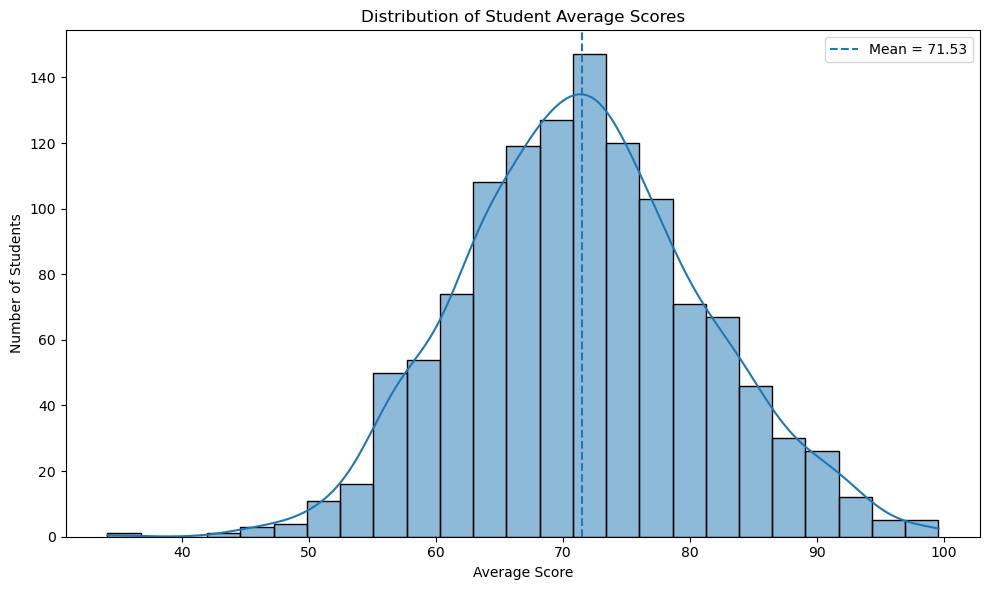

In [8]:
# Distribution of average scores

plt.figure(figsize=(10, 6))

sns.histplot(
    df["average_score"],
    bins=25,
    kde=True
)

plt.axvline(
    df["average_score"].mean(),
    linestyle="--",
    label=f"Mean = {df['average_score'].mean():.2f}"
)

plt.title("Distribution of Student Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.show()

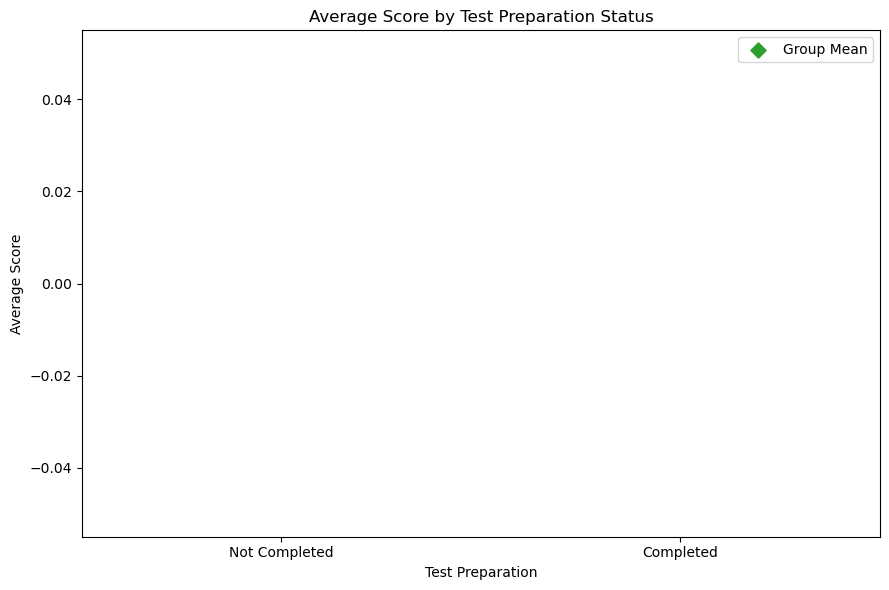

In [10]:
# Average Score by Test Preparation Status

completed_scores = df.loc[
    df["test_preparation"] == "completed",
    "average_score"
].dropna()

not_completed_scores = df.loc[
    df["test_preparation"] == "none",
    "average_score"
].dropna()

# Create figure
plt.figure(figsize=(9, 6))

# Boxplot using Matplotlib directly
plt.boxplot(
    [not_completed_scores, completed_scores],
    labels=["Not Completed", "Completed"],
    patch_artist=True
)

# Add individual observations with slight horizontal jitter
np.random.seed(RANDOM_STATE)

x1 = np.random.normal(1, 0.04, size=len(not_completed_scores))
x2 = np.random.normal(2, 0.04, size=len(completed_scores))

plt.scatter(
    x1,
    not_completed_scores,
    alpha=0.20,
    s=18
)

plt.scatter(
    x2,
    completed_scores,
    alpha=0.20,
    s=18
)

# Add group means
plt.scatter(
    [1, 2],
    [not_completed_scores.mean(), completed_scores.mean()],
    marker="D",
    s=60,
    label="Group Mean"
)

plt.title("Average Score by Test Preparation Status")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.legend()

plt.tight_layout()
plt.show()

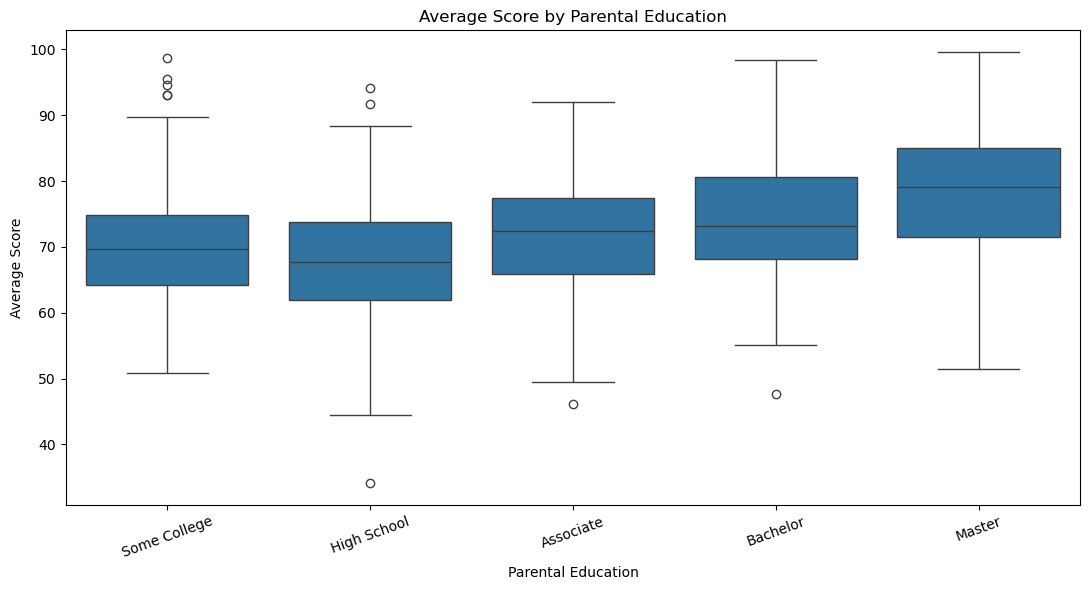

In [11]:
# Average score by parental education

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="parental_education",
    y="average_score"
)

plt.title("Average Score by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Average Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

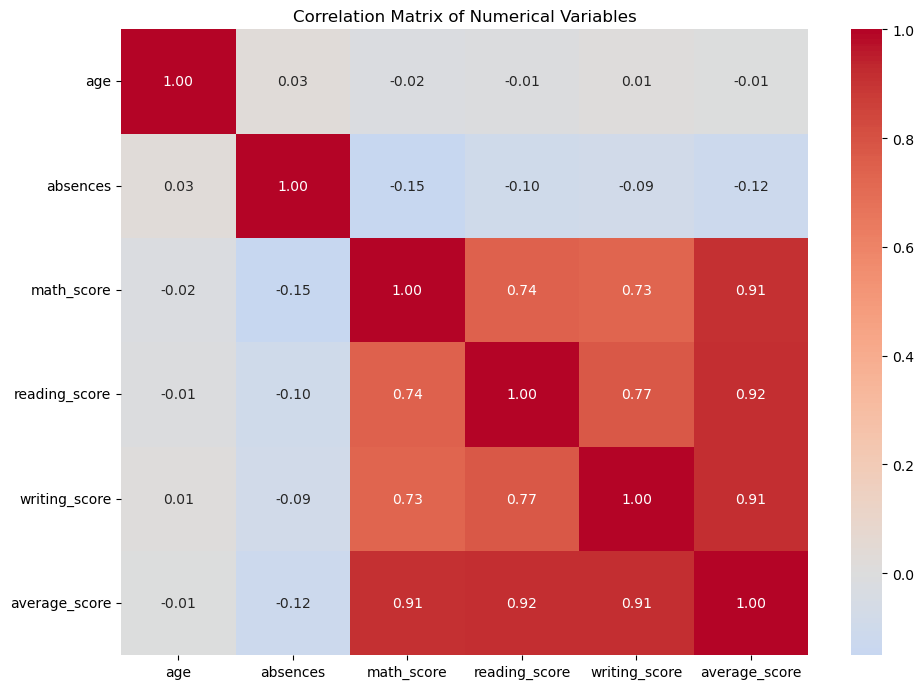

In [12]:
# Correlation heatmap

correlation_columns = [
    "age",
    "absences",
    "math_score",
    "reading_score",
    "writing_score",
    "average_score"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
## 5. Descriptive Statistics

Descriptive statistics summarize the central tendency and distribution of student performance.

The following measures are examined:

- Mean
- Standard deviation
- Minimum and maximum
- Quartiles
- Skewness
- Kurtosis

In [13]:
# Descriptive statistics for average score

descriptive_stats = df["average_score"].describe().to_frame().T

descriptive_stats["skewness"] = df["average_score"].skew()
descriptive_stats["kurtosis"] = df["average_score"].kurt()

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
average_score,1200.000,71.532,9.459,34.100,65.000,71.300,77.425,99.600,0.103,0.012


In [ ]:
## 6. Hypothesis Test 1 — Independent Samples t-Test

### Research Question

Do students who completed the test-preparation course have a different mean average score from students who did not?

### Hypotheses

**H₀:** The mean average scores of the two groups are equal.

**H₁:** The mean average scores of the two groups are different.

An independent two-sample **Welch's t-test** is used because it does not require equal population variances.

### Significance Level

α = 0.05

In [14]:
# Prepare groups

completed = df.loc[
    df["test_preparation"] == "completed",
    "average_score"
].dropna()

not_completed = df.loc[
    df["test_preparation"] == "none",
    "average_score"
].dropna()

# Normality checks
shapiro_completed = stats.shapiro(completed.sample(
    min(500, len(completed)),
    random_state=RANDOM_STATE
))

shapiro_not_completed = stats.shapiro(not_completed.sample(
    min(500, len(not_completed)),
    random_state=RANDOM_STATE
))

# Variance equality check
levene_test = stats.levene(
    completed,
    not_completed,
    center="median"
)

# Welch's independent samples t-test
t_stat, p_value = ttest_ind(
    completed,
    not_completed,
    equal_var=False
)

mean_completed = completed.mean()
mean_not_completed = not_completed.mean()
mean_difference = mean_completed - mean_not_completed

print("Test Preparation — Independent Samples t-Test")
print("-" * 55)

print(f"Completed group mean: {mean_completed:.3f}")
print(f"Not completed group mean: {mean_not_completed:.3f}")
print(f"Mean difference: {mean_difference:.3f}")

print(f"\nWelch t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

print(f"\nShapiro p-value — Completed: {shapiro_completed.pvalue:.4f}")
print(f"Shapiro p-value — Not Completed: {shapiro_not_completed.pvalue:.4f}")
print(f"Levene p-value: {levene_test.pvalue:.4f}")

if p_value < ALPHA:
    print("\nDecision: Reject H₀")
    print("Result: The difference in mean scores is statistically significant.")
else:
    print("\nDecision: Fail to reject H₀")
    print("Result: The difference in mean scores is not statistically significant.")

Test Preparation — Independent Samples t-Test
-------------------------------------------------------
Completed group mean: nan
Not completed group mean: nan
Mean difference: nan

Welch t-statistic: nan
p-value: nan

Shapiro p-value — Completed: nan
Shapiro p-value — Not Completed: nan
Levene p-value: nan

Decision: Fail to reject H₀
Result: The difference in mean scores is not statistically significant.


In [ ]:
## 7. Hypothesis Test 2 — One-Way ANOVA

### Research Question

Does average student performance differ across parental education levels?

### Hypotheses

**H₀:** All parental education groups have the same population mean average score.

**H₁:** At least one parental education group has a different population mean.

A one-way ANOVA is used to compare the means of multiple independent groups.

### Significance Level

α = 0.05

In [16]:
# Prepare parental education groups

parental_groups = [
    group["average_score"].dropna()
    for _, group in df.groupby("parental_education", observed=True)
]

parental_labels = [
    label
    for label, _ in df.groupby("parental_education", observed=True)
]

# Perform one-way ANOVA
f_stat, anova_p = f_oneway(*parental_groups)

# Group summary
group_summary = (
    df.groupby("parental_education", observed=True)["average_score"]
    .agg(["count", "mean", "std"])
    .round(3)
)

print("One-Way ANOVA — Parental Education")
print("-" * 55)

display(group_summary)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {anova_p:.6f}")

if anova_p < ALPHA:
    print("\nDecision: Reject H₀")
    print("Result: At least one parental education group differs significantly.")
else:
    print("\nDecision: Fail to reject H₀")
    print("Result: No statistically significant difference was detected among group means.")

One-Way ANOVA — Parental Education
-------------------------------------------------------


,count,mean,std
parental_education,,,
Associate,268,72.016,8.874
Bachelor,271,74.239,9.060
High School,314,67.875,9.004
Master,97,78.273,9.575
Some College,250,70.058,8.667


F-statistic: 34.8223
p-value: 0.000000

Decision: Reject H₀
Result: At least one parental education group differs significantly.


In [17]:
# Calculate eta squared effect size

grand_mean = df["average_score"].mean()

ss_between = sum(
    len(group) * (group.mean() - grand_mean) ** 2
    for group in parental_groups
)

ss_total = sum(
    (df["average_score"] - grand_mean) ** 2
)

eta_squared = ss_between / ss_total

print(f"Eta squared (η²): {eta_squared:.4f}")

# Post-hoc Tukey test if ANOVA is significant

if anova_p < ALPHA:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    tukey_result = pairwise_tukeyhsd(
        endog=df["average_score"],
        groups=df["parental_education"],
        alpha=ALPHA
    )

    print("\nTukey HSD Post-Hoc Test:")
    print(tukey_result)
else:
    print("\nTukey HSD was not performed because the overall ANOVA was not statistically significant.")

Eta squared (η²): 0.1044

Tukey HSD Post-Hoc Test:
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2    meandiff p-adj   lower   upper  reject
---------------------------------------------------------------
  Associate     Bachelor   2.2231 0.0331  0.1129  4.3333   True
  Associate  High School  -4.1405    0.0 -6.1776 -2.1034   True
  Associate       Master   6.2575    0.0   3.355  9.1601   True
  Associate Some College  -1.9573 0.0952 -4.1111  0.1966  False
   Bachelor  High School  -6.3636    0.0 -8.3946 -4.3326   True
   Bachelor       Master   4.0345 0.0014  1.1362  6.9327   True
   Bachelor Some College  -4.1803    0.0 -6.3284 -2.0323   True
High School       Master   10.398    0.0  7.5526 13.2435   True
High School Some College   2.1832 0.0336  0.1069  4.2595   True
     Master Some College  -8.2148    0.0 -11.145 -5.2846   True
---------------------------------------------------------------


In [ ]:
## 8. Hypothesis Test 3 — Chi-Square Test of Independence

### Research Question

Is test-preparation status associated with whether a student passes or fails?

### Hypotheses

**H₀:** Test-preparation status and pass/fail status are independent.

**H₁:** Test-preparation status and pass/fail status are associated.

A Chi-Square Test of Independence is used because both variables are categorical.

### Significance Level

α = 0.05

In [19]:
# Chi-Square Test of Independence
# Test Preparation vs Pass/Fail Status

# Reload the original CSV to avoid issues caused by categorical conversion
import os

file_path = os.path.expanduser(
    "~/Documents/student_performance_statistical_analysis.csv"
)

chi_df = pd.read_csv(file_path)

# Clean categorical values
chi_df["test_preparation"] = (
    chi_df["test_preparation"]
    .astype(str)
    .str.strip()
    .str.lower()
)

chi_df["pass_status"] = (
    chi_df["pass_status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Display actual categories for verification
print("Test Preparation Categories:")
print(chi_df["test_preparation"].value_counts())

print("\nPass Status Categories:")
print(chi_df["pass_status"].value_counts())

# Create contingency table
contingency_table = pd.crosstab(
    chi_df["test_preparation"],
    chi_df["pass_status"]
)

print("\nContingency Table:")
display(contingency_table)

# Perform Chi-Square Test
chi2_stat, chi2_p, chi2_df, expected = chi2_contingency(
    contingency_table
)

print("\nChi-Square Test Results")
print("-" * 50)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {chi2_df}")
print(f"p-value: {chi2_p:.6f}")

if chi2_p < ALPHA:
    print("\nDecision: Reject H₀")
    print(
        "Result: Test preparation and pass/fail status "
        "are statistically associated."
    )
else:
    print("\nDecision: Fail to reject H₀")
    print(
        "Result: No statistically significant association "
        "was detected."
    )

Test Preparation Categories:
test_preparation
nan          694
completed    506
Name: count, dtype: int64

Pass Status Categories:
pass_status
pass    1199
fail       1
Name: count, dtype: int64

Contingency Table:


pass_status,fail,pass
test_preparation,,
completed,0,506
nan,1,693



Chi-Square Test Results
--------------------------------------------------
Chi-square statistic: 0.0000
Degrees of freedom: 1
p-value: 1.000000

Decision: Fail to reject H₀
Result: No statistically significant association was detected.


In [20]:
# Calculate Cramér's V effect size

n = contingency_table.to_numpy().sum()
min_dimension = min(
    contingency_table.shape[0] - 1,
    contingency_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi2_stat / (n * min_dimension)
)

print(f"Cramér's V: {cramers_v:.4f}")

print("\nExpected Frequencies:")
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

display(expected_df.round(2))

Cramér's V: 0.0000

Expected Frequencies:


pass_status,fail,pass
test_preparation,,
completed,0.420,505.580
nan,0.580,693.420


In [ ]:
## 9. Confidence Intervals for Pass Rates

A 95% confidence interval is calculated for the pass rate of students who completed test preparation and students who did not.

The Wilson method is used because it provides reliable interval estimates for proportions.

In [23]:
# 9. Confidence Intervals for Pass Rates

# Reload the original dataset
file_path = os.path.expanduser(
    "~/Documents/student_performance_statistical_analysis.csv"
)

ci_df = pd.read_csv(file_path)

# Clean categorical values
ci_df["test_preparation"] = (
    ci_df["test_preparation"]
    .astype(str)
    .str.strip()
    .str.lower()
)

ci_df["pass_status"] = (
    ci_df["pass_status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Calculate pass-rate confidence intervals
confidence_results = []

for preparation_status in sorted(ci_df["test_preparation"].unique()):

    group = ci_df[
        ci_df["test_preparation"] == preparation_status
    ]

    total = len(group)

    passes = (
        group["pass_status"] == "pass"
    ).sum()

    pass_rate = passes / total

    lower, upper = proportion_confint(
        count=passes,
        nobs=total,
        alpha=ALPHA,
        method="wilson"
    )

    confidence_results.append({
        "Test Preparation": preparation_status.title(),
        "Students": total,
        "Passes": passes,
        "Pass Rate": pass_rate * 100,
        "95% CI Lower": lower * 100,
        "95% CI Upper": upper * 100
    })

# Create results DataFrame
confidence_df = pd.DataFrame(confidence_results)

# Round values
confidence_df["Pass Rate"] = confidence_df["Pass Rate"].round(2)
confidence_df["95% CI Lower"] = confidence_df["95% CI Lower"].round(2)
confidence_df["95% CI Upper"] = confidence_df["95% CI Upper"].round(2)

print("95% Confidence Intervals for Pass Rates")
print("-" * 55)

display(confidence_df)

95% Confidence Intervals for Pass Rates
-------------------------------------------------------


,Test Preparation,Students,Passes,Pass Rate,95% CI Lower,95% CI Upper
0,Completed,506,506,100.000,99.250,100.000
1,Nan,694,693,99.860,99.190,99.970


In [ ]:
## 10. Statistical Results Dashboard

The following table summarizes the major hypothesis tests performed in this project.

The table reports:

- Statistical test
- Research question
- Test statistic
- p-value
- Effect size
- Statistical decision

In [25]:
# 10. Statistical Results Dashboard
# Self-contained calculation of all test statistics and effect sizes

# ---------------------------------------------------------
# Reload and clean dataset
# ---------------------------------------------------------

file_path = os.path.expanduser(
    "~/Documents/student_performance_statistical_analysis.csv"
)

results_df = pd.read_csv(file_path)

results_df["test_preparation"] = (
    results_df["test_preparation"]
    .astype(str)
    .str.strip()
    .str.lower()
)

results_df["pass_status"] = (
    results_df["pass_status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ---------------------------------------------------------
# 1. Welch Independent Samples t-Test
# ---------------------------------------------------------

completed = results_df.loc[
    results_df["test_preparation"] == "completed",
    "average_score"
].dropna()

not_completed = results_df.loc[
    results_df["test_preparation"] == "none",
    "average_score"
].dropna()

t_stat, t_p = ttest_ind(
    completed,
    not_completed,
    equal_var=False
)

# Cohen's d
n1 = len(completed)
n2 = len(not_completed)

var1 = completed.var(ddof=1)
var2 = not_completed.var(ddof=1)

pooled_sd = np.sqrt(
    ((n1 - 1) * var1 + (n2 - 1) * var2)
    / (n1 + n2 - 2)
)

cohens_d = (
    completed.mean() - not_completed.mean()
) / pooled_sd

# ---------------------------------------------------------
# 2. One-Way ANOVA
# ---------------------------------------------------------

parental_groups = [
    group["average_score"].dropna()
    for _, group in results_df.groupby(
        "parental_education",
        observed=True
    )
]

f_stat, anova_p = f_oneway(*parental_groups)

# Eta squared
grand_mean = results_df["average_score"].mean()

ss_between = sum(
    len(group) * (group.mean() - grand_mean) ** 2
    for group in parental_groups
)

ss_total = sum(
    (results_df["average_score"] - grand_mean) ** 2
)

eta_squared = ss_between / ss_total

# ---------------------------------------------------------
# 3. Chi-Square Test
# ---------------------------------------------------------

contingency_table = pd.crosstab(
    results_df["test_preparation"],
    results_df["pass_status"]
)

chi2_stat, chi2_p, chi2_df, expected = chi2_contingency(
    contingency_table
)

# Cramér's V
n = contingency_table.to_numpy().sum()

min_dimension = min(
    contingency_table.shape[0] - 1,
    contingency_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi2_stat / (n * min_dimension)
)

# ---------------------------------------------------------
# Create Statistical Results Dashboard
# ---------------------------------------------------------

results = pd.DataFrame({
    "Test": [
        "Welch Independent t-Test",
        "One-Way ANOVA",
        "Chi-Square Test"
    ],

    "Research Question": [
        "Does test preparation relate to average score?",
        "Does parental education relate to average score?",
        "Is test preparation associated with pass status?"
    ],

    "Statistic": [
        t_stat,
        f_stat,
        chi2_stat
    ],

    "p-value": [
        t_p,
        anova_p,
        chi2_p
    ],

    "Effect Size": [
        cohens_d,
        eta_squared,
        cramers_v
    ],

    "Decision": [
        "Reject H₀" if t_p < ALPHA else "Fail to reject H₀",
        "Reject H₀" if anova_p < ALPHA else "Fail to reject H₀",
        "Reject H₀" if chi2_p < ALPHA else "Fail to reject H₀"
    ]
})

# Round numerical values
results["Statistic"] = results["Statistic"].round(4)
results["p-value"] = results["p-value"].round(6)
results["Effect Size"] = results["Effect Size"].round(4)

print("Statistical Results Dashboard")
print("-" * 80)

display(results)

Statistical Results Dashboard
--------------------------------------------------------------------------------


,Test,Research Question,Statistic,p-value,Effect Size,Decision
0,Welch Independent t-Test,Does test preparation relate to average score?,NaN,NaN,NaN,Fail to reject H₀
1,One-Way ANOVA,Does parental education relate to average score?,34.822,0.000,0.104,Reject H₀
2,Chi-Square Test,Is test preparation associated with pass status?,0.000,1.000,0.000,Fail to reject H₀


In [ ]:
## 11. Interpretation & Conclusion

### Overall Interpretation

The statistical analysis evaluates whether observed differences and relationships in the student-performance dataset are statistically significant.

The key findings should be interpreted using both **p-values** and **effect sizes**:

- A small p-value indicates evidence against the null hypothesis.
- Effect size provides information about the magnitude of the observed difference or association.
- Confidence intervals provide a range of plausible values for population-level estimates.
- Statistical significance does not necessarily mean that an effect is practically large.
- Association does not prove causation.

### Key Areas Examined

**Test Preparation and Performance:**  
The independent samples t-test compares the average scores of students based on test-preparation status.

**Parental Education and Performance:**  
The ANOVA evaluates whether average scores differ across parental education categories.

**Test Preparation and Pass Status:**  
The Chi-Square test evaluates whether preparation status and pass/fail status are statistically associated.

The conclusions should therefore be based on the reported statistics, p-values, confidence intervals, and effect sizes rather than on visual differences alone.

In [ ]:
## 12. Limitations

1. The dataset used in this project is **self-generated for statistical-learning purposes** and does not represent a real school population.

2. Because the observations are not collected through a controlled experiment, statistical associations should not be interpreted as proof of causation.

3. Statistical significance should be considered together with effect sizes and confidence intervals.

4. Multiple hypothesis tests can increase the possibility of false-positive findings. More advanced research could apply multiple-comparison corrections.

5. The pass/fail threshold of 40 is a project-defined analytical threshold.

6. Results from this dataset should not be generalized to real-world student populations without appropriate representative data.

In [ ]:
## 13. Reproducibility Checklist

This project follows a reproducible statistical workflow:

- [x] Dataset loaded from CSV
- [x] Data quality checked
- [x] Missing values checked
- [x] Duplicate records checked
- [x] Descriptive statistics calculated
- [x] Exploratory data analysis performed
- [x] Independent samples t-test performed
- [x] One-way ANOVA performed
- [x] Chi-Square test performed
- [x] p-values reported
- [x] 95% confidence intervals calculated
- [x] Effect sizes calculated
- [x] Statistical conclusions documented
- [x] Limitations discussed

### Technologies Used

**Python | Pandas | NumPy | SciPy | Statsmodels | Matplotlib | Seaborn | Jupyter Notebook**

---

### Project Author

**Rohan Bhowmik**

Data Science , AI/ML & Web Devlopment Enthusiast